# Análisis Predictivo - Evaluación 3

El archivo que se le suministra es un conjunto de datos de pacientes con cáncer de mama se obtuvo de la actualización de noviembre de 2017 del Programa SEER del NCI, que proporciona información sobre estadísticas de cáncer basadas en la población. El conjunto de datos incluyó a pacientes de sexo femenino con cáncer de mama de carcinoma lobular y ductal infiltrante (códigos histológicos 8522/3 de recodificación NOS de citas primarias del SEER) diagnosticado entre 2006 y 2010.

Las variables que contiene este dataset son:

1. Age: Se refiere a la edad del paciente en el momento del diagnóstico.
2. Race: raza o etnia del paciente.
3. Marital Status: El estado civil del paciente (casado, soltero, divorciado, etc.).
4. T Stage: La clasificación del tamaño o extensión del tumor primario (normalmente se utiliza en el sistema TNM).
5. N Stage: Se refiere a la extensión del cáncer a los ganglios linfáticos cercanos.
6. 6th State: Puede referirse al estadio del cáncer según una clasificación específica (como la clasificación AJCC).
7. differentiate: Se refiere al grado de diferenciación celular del tumor (lo diferentes que son las células tumorales de las células normales), un factor utilizado para determinar la agresividad del cáncer.
8. Grade: Se refiere al grado de progresión del tumor o cáncer y a cuánto se ha extendido.
9. A Stage: Puede referirse a un estadio específico en la clasificación por estadios del cáncer.
10. Tumor Size: El tamaño medido del tumor primario.
11. Estrogen Status: Estado de los receptores de estrógenos en las células cancerosas (positivo o negativo), que afecta al tratamiento.
12. Progesterone Status: Estado de los receptores de progesterona en las células cancerosas (positivo o negativo).
13. Regional Node Examined: El número de ganglios linfáticos examinados para detectar la propagación del cáncer.
14. Reginol Node Positive: El número de ganglios linfáticos que dieron positivo para el cáncer.
15. Survival Monyhs: El número de meses que el paciente estuvo vivo después del diagnóstico.
16. Status: El estado final del paciente (como supervivencia o muerte).

In [1]:
from pathlib import Path

import pandas as pd

DATA_DIR = Path().resolve().parent / 'data' / 'raw'
file_name = 'Breast_Cancer_dataset.csv'
file_path = DATA_DIR / file_name

df = pd.read_csv(DATA_DIR / file_path, sep=';', na_values=' ',)
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4.0,Positive,Positive,24.0,1.0,60.0,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35.0,Positive,Positive,14.0,5.0,NaN,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63.0,Positive,Positive,14.0,7.0,75.0,Alive
3,58,NaN,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18.0,Positive,Positive,2.0,1.0,84.0,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,NaN,41.0,Positive,Positive,3.0,1.0,50.0,Alive


Se creo un modelo de regresión logística para predecir la variable **Status**, con los siguientes resultados:

```
                precision    recall  f1-score   support

       Alive       0.95      0.81      0.88       678
        Dead       0.42      0.76      0.54       121

    accuracy                           0.80       799
   macro avg       0.69      0.79      0.71       799
weighted avg       0.87      0.80      0.83       799

```

### EDA

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4024 non-null   int64  
 1   Race                    4023 non-null   object 
 2   Marital Status          4022 non-null   object 
 3   T Stage                 4024 non-null   object 
 4   N Stage                 4024 non-null   object 
 5   6th Stage               4024 non-null   object 
 6   differentiate           4023 non-null   object 
 7   Grade                   4024 non-null   object 
 8   A Stage                 4003 non-null   object 
 9   Tumor Size              4005 non-null   float64
 10  Estrogen Status         4004 non-null   object 
 11  Progesterone Status     4003 non-null   object 
 12  Regional Node Examined  4005 non-null   float64
 13  Reginol Node Positive   4005 non-null   float64
 14  Survival Months         4003 non-null   

In [3]:
df.isnull().sum()

Age                        0
Race                       1
Marital Status             2
T Stage                    0
N Stage                    0
6th Stage                  0
differentiate              1
Grade                      0
A Stage                   21
Tumor Size                19
Estrogen Status           20
Progesterone Status       21
Regional Node Examined    19
Reginol Node Positive     19
Survival Months           21
Status                    19
dtype: int64

In [4]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4005.000000,4005.000000,4005.000000,4003.000000
mean,53.972167,30.408739,14.356554,4.148564,71.338246
std,8.963134,21.078678,8.093220,5.107061,22.868986
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [5]:
df.describe(include='object').T

,count,unique,top,freq
Race,4023,3,White,3412
Marital Status,4022,5,Married,2641
T Stage,4024,4,T2,1786
N Stage,4024,3,N1,2732
6th Stage,4024,5,IIA,1305
differentiate,4023,4,Moderately differentiated,2351
Grade,4024,4,2,2351
A Stage,4003,2,Regional,3911
Estrogen Status,4004,2,Positive,3740
Progesterone Status,4003,2,Positive,3309


In [6]:
for col in df.select_dtypes(include='object').columns:
    print(df[col].value_counts(), '\n')

Race
White    3412
Other     320
Black     291
Name: count, dtype: int64 

Marital Status
Married      2641
Single        615
Divorced      486
Widowed       235
Separated      45
Name: count, dtype: int64 

T Stage 
T2    1786
T1    1603
T3     533
T4     102
Name: count, dtype: int64 

N Stage
N1    2732
N2     820
N3     472
Name: count, dtype: int64 

6th Stage
IIA     1305
IIB     1130
IIIA    1050
IIIC     472
IIIB      67
Name: count, dtype: int64 

differentiate
Moderately differentiated    2351
Poorly differentiated        1110
Well differentiated           543
Undifferentiated               19
Name: count, dtype: int64 

Grade
2              2351
3              1111
1               543
 anaplastic      19
Name: count, dtype: int64 

A Stage
Regional    3911
Distant       92
Name: count, dtype: int64 

Estrogen Status
Positive    3740
Negative     264
Name: count, dtype: int64 

Progesterone Status
Positive    3309
Negative     694
Name: count, dtype: int64 

Status
Alive    3

# Parte 1

Haga un modelo de bosque aleatorio para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-macro score del modelo de regresión logísitca. Así:
- Si el f1-macro score obtenido es menor a 0.71, la máxima nota que obtendrá es 3.0.
- Si el f1-macro score obtenido es menor a 0.74, la máxima nota que obtendrá es 4.0.
- Si el f1-macro score obtenido es menor a 0.76, la máxima nota que obtendrá es 4.5.

#### Random Forest
Primero se limpian los datos nulos de la variable a predecir, se parten los datos y luego se procesan 

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_dropna = df.dropna()

X = df_dropna.drop(columns=['Status'])
y = df_dropna['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

print(X_train.shape)
print(X_test.shape)

(3196, 15)
(799, 15)


Best validation score: 0.779 with parameters: {'classifier__n_estimators': 67, 'classifier__min_samples_split': 8, 'classifier__max_features': 'log2', 'classifier__max_depth': 7, 'classifier__class_weight': {0: 1, 1: 5}}
Train score: 0.832
Test score: 0.766
              precision    recall  f1-score   support

       Alive       0.93      0.93      0.93       678
        Dead       0.60      0.60      0.60       121

    accuracy                           0.88       799
   macro avg       0.77      0.77      0.77       799
weighted avg       0.88      0.88      0.88       799



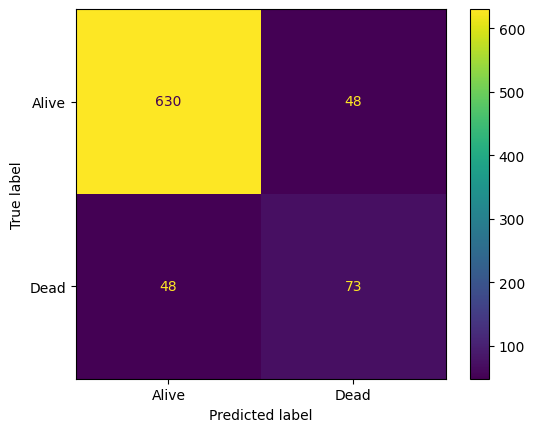

In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

ohe = OneHotEncoder(
    sparse_output=False,
    drop='if_binary'
    )

cat_vars = X_train.select_dtypes(include='object').columns.to_list()

preprocessor = ColumnTransformer(
    transformers=[
        ('cod_oh', ohe, cat_vars),
    ],
    remainder='passthrough'
    )

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=1))
])

dist = {
    'classifier__n_estimators':range(10, 200),
    'classifier__max_depth': range(3,8),
    'classifier__min_samples_split': range(2, 10),
    #'classifier__ccp_alpha': loguniform(1e-4, 1e2),
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 15}]
    }

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=dist,
    scoring='f1_macro',
    n_iter=20,
    random_state=1
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [9]:
best_rf_model = random_search.best_estimator_
importances = best_rf_model.named_steps['classifier'].feature_importances_
features = best_rf_model.named_steps['preprocessor'].get_feature_names_out()

importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importances_df = importances_df[importances_df['Importance'] > 0]
importances_df.sort_values('Importance', ascending=False).head(10)

,Feature,Importance
33,remainder__Survival Months,0.473420
32,remainder__Reginol Node Positive,0.055956
29,remainder__Age,0.049867
12,cod_oh__N Stage_N1,0.047970
30,remainder__Tumor Size,0.045731
31,remainder__Regional Node Examined,0.038859
28,cod_oh__Progesterone Status_Positive,0.033123
14,cod_oh__N Stage_N3,0.030973
19,cod_oh__6th Stage_IIIC,0.023335
25,cod_oh__Grade_3,0.022230


# Parte 2
 
Haga un modelo de boosting para predecir la variable **Status**.

Particione los datos en una proporción 80/20, haciendo `random_state=1`, y `stratify=y`.

El modelo debe ser sintonizado.

Reporte:
- El score de validación y los valores de los hiperparámetros sintonizados.
- El score de entrenamiento.
- El score de prueba.
- La matriz de confusión
- El reporte de clasificación.
- La importancia relativa de cada característica del modelo en un dataframe.

El objetivo es que el modelo supere el f1-macro score del modelo de regresión logísitca. Así:
- Si el f1-macro score obtenido es menor a 0.75, la máxima nota que obtendrá es 3.0.
- Si el f1-macro obtenido es menor a 0.77, la máxima nota que obtendrá es 4.0.
- Si el f1-macro obtenido es menor a 0.79, la máxima nota que obtendrá es 4.5.

#### AdaBoost
LLega solo a 0.75, falta un balanceo de clases

Best validation score: 0.791 with parameters: {'classifier__learning_rate': np.float64(0.5854751355295726), 'classifier__n_estimators': 44}
Train score: 0.790
Test score: 0.755
              precision    recall  f1-score   support

       Alive       0.91      0.96      0.94       678
        Dead       0.69      0.49      0.57       121

    accuracy                           0.89       799
   macro avg       0.80      0.72      0.75       799
weighted avg       0.88      0.89      0.88       799



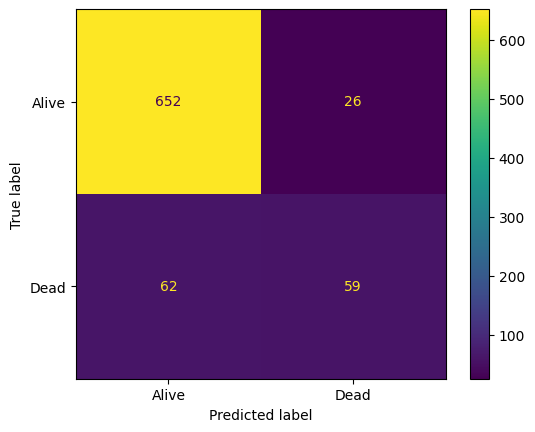

In [10]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    random_state=1,
    )

ada_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', ada)
])

dist = {
    'classifier__learning_rate':loguniform(1e-3, 10),
    'classifier__n_estimators': range(1, 200)
    }

random_search = RandomizedSearchCV(
    estimator=ada_model,
    param_distributions=dist,
    scoring='f1_macro',
    n_iter=20,
    random_state=1
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

#### Gradient Boosting
Tampoco llega la meta 

Best validation score: 0.788 with parameters: {'classifier__learning_rate': np.float64(0.1181980184396901), 'classifier__min_samples_split': 2, 'classifier__n_estimators': 61}
Train score: 0.821
Test score: 0.767
              precision    recall  f1-score   support

       Alive       0.91      0.97      0.94       678
        Dead       0.77      0.48      0.59       121

    accuracy                           0.90       799
   macro avg       0.84      0.73      0.77       799
weighted avg       0.89      0.90      0.89       799



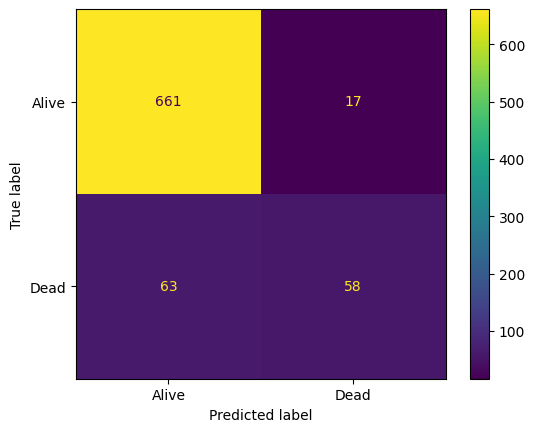

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    #n_estimators=50,
    #max_depth=3,
    random_state=1,
    n_iter_no_change=10,
    validation_fraction=0.1,
    )

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gb)
])

dist = {
    'classifier__n_estimators':range(1, 201),
    'classifier__learning_rate':loguniform(1e-3,10),
    'classifier__min_samples_split':range(2,10)
    }

random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=dist,
    random_state=1,
    scoring='f1_macro',
    n_iter=20
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

#### XGBoost

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = df.dropna(subset=['Status'])

X = df.drop('Status', axis = 1)
y = df['Status']

categorical_features = X.select_dtypes(include='object').columns.to_list()
X[categorical_features] = X[categorical_features].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

X_train_cv, X_val, y_train_cv, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=1,
    stratify=y_train
    )

print(X_train.shape)
print(X_test.shape)

(3204, 15)
(801, 15)


In [14]:
import sys
print(sys.executable)

c:\Users\saram\repos\ap-2026-1-62\.venv\Scripts\python.exe


In [15]:
import sys
!{sys.executable} -m pip install xgboost

c:\Users\saram\repos\ap-2026-1-62\.venv\Scripts\python.exe: No module named pip


Best validation score: 0.795 with parameters: {'colsample_bytree': np.float64(0.8777315263012332), 'gamma': np.float64(3.769380942306232), 'learning_rate': np.float64(0.1933943115144068), 'max_delta_step': 9, 'max_depth': 5, 'min_child_weight': 9, 'n_estimators': 358, 'reg_alpha': np.float64(0.0026881977410454245), 'reg_lambda': np.float64(0.10945638802254011), 'scale_pos_weight': np.float64(2.02135232538193), 'subsample': np.float64(0.644358916352805)}
Train score: 0.813
Test score: 0.785
              precision    recall  f1-score   support

       Alive       0.93      0.95      0.94       680
        Dead       0.66      0.60      0.63       121

    accuracy                           0.89       801
   macro avg       0.80      0.77      0.79       801
weighted avg       0.89      0.89      0.89       801



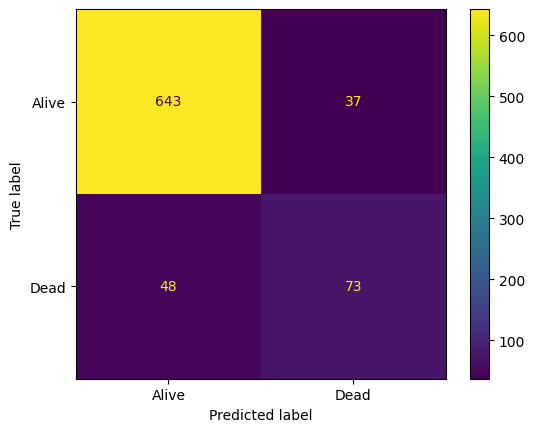

In [16]:
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

model = XGBClassifier(
    grow_policy='lossguide',
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=10,
    random_state=1,
    )

dist = {
    'n_estimators':randint(1,500),
    'max_depth':randint(3,10),
    'learning_rate':loguniform(0.001,0.3),
    'subsample':uniform(0.5,0.5),
    'colsample_bytree':uniform(0.5,0.5),
    'min_child_weight':randint(5,10),
    'gamma':uniform(0,5),
    'reg_alpha':loguniform(1e-3,10),
    'reg_lambda':loguniform(1e-3,10),
    'scale_pos_weight':uniform(1,10), #Balanceo de clases
    'max_delta_step':randint(0,10),
    }

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=dist,
    random_state=1,
    n_iter=20,
    scoring='f1_macro'
    )

random_search.fit(
    X_train_cv,
    y_train_cv,
    eval_set=[(X_val, y_val)],
    verbose=False
    )

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

In [17]:
best_rf_model = random_search.best_estimator_
importances = best_rf_model.feature_importances_
features = X_train.columns.to_list()

importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importances_df = importances_df[importances_df['Importance'] > 0]
importances_df.sort_values('Importance', ascending=False).head(10)

,Feature,Importance
14,Survival Months,0.301950
5,6th Stage,0.079433
11,Progesterone Status,0.066500
6,differentiate,0.062855
1,Race,0.055980
4,N Stage,0.054961
13,Reginol Node Positive,0.053577
10,Estrogen Status,0.050034
0,Age,0.049454
12,Regional Node Examined,0.048146


#### LightGBM

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

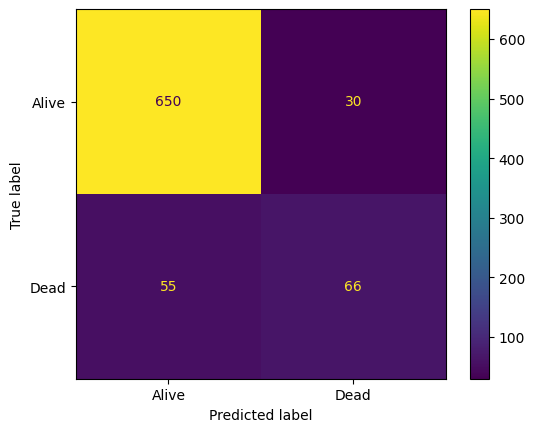

In [19]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    objective='binary',
    verbose=0,
    random_state=1,
    scale_pos_weight=sum(y_train==0) / sum(y_train==1)
    )

param_distributions = {
    'num_leaves': randint(20, 150),
    'max_depth': randint(3, 15),
    'learning_rate': loguniform(0.01, 0.3),
    'n_estimators': randint(50, 500),
    'min_child_samples': randint(2, 50),
    'subsample': uniform(0.5, 0.5),  # de 0.5 a 1.0
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': loguniform(1e-3, 10),
    'reg_lambda': loguniform(1e-3, 10),
#   'scale_pos_weight': uniform(1, 10)  # Solo si hay desbalance
}

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1_macro',
    random_state=1
    )

random_search.fit(
    X_train_cv,
    y_train_cv,
    categorical_feature=categorical_features,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10)],
    )

print(f'Best validation score: {random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

print(classification_report(
    y_test,
    random_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

ConfusionMatrixDisplay.from_estimator(
    random_search.best_estimator_,
    X_test,
    y_test,
    display_labels=le.classes_
    );

# Condiciones de entrega de la evaluación:

- Debe entregar un archivo en formato .ipynb. No se admiten URLs.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura (código redundante, funciones innecesarias, versiones preliminares de modelos). Solo entregue el código que de respuesta a lo que se le pide que haga.